In [2]:
from pathlib import Path
import numpy as np
import polars as pl
from sklearn.preprocessing import LabelEncoder
from src.tennis import fetch_jeff_sackmann_atp_data, read_tennis_data

In [3]:
files = fetch_jeff_sackmann_atp_data(dest_dir="data/atp_raw", start_year=2000, end_year=2025)

In [4]:
df_tennis = read_tennis_data(files)

In [5]:
df_tennis = df_tennis.with_columns([
    df_tennis["tourney_date"].cast(str).str.strptime(pl.Date, "%Y%m%d").alias("date"),
    (df_tennis['w_1stWon'] + df_tennis['w_2ndWon']).alias("w_serve_won"),
    (df_tennis['l_1stWon'] + df_tennis['l_2ndWon']).alias("l_serve_won"),
    ])

df_tennis = df_tennis.filter(pl.col("tourney_level").is_in(["G", "M", "A"]))
df_tennis = df_tennis.filter(pl.col("surface").is_in(["Hard", "Clay", "Grass"]))

In [6]:
# drop davis cup (D)
# drop final/season ending events (F) 
df_tennis['tourney_level'].value_counts()

tourney_level,count
str,u32
"""G""",13081
"""A""",41141
"""M""",14444


In [7]:
# create a link between winner_id -> winner_name, and loser_id -> loser_name. 
# I want a dataframe of unique player ids and names
def get_player_id_name_df(df: pl.DataFrame) -> pl.DataFrame:
    winner_df = df.select([
        pl.col("winner_id").alias("player_id"),
        pl.col("winner_name").alias("player_name")
    ]).unique()

    loser_df = df.select([
        pl.col("loser_id").alias("player_id"),
        pl.col("loser_name").alias("player_name")
    ]).unique()

    player_df = pl.concat([winner_df, loser_df]).unique().sort("player_id")

    return player_df

In [8]:
link_player_df = get_player_id_name_df(df_tennis)

In [9]:
link_player_df

player_id,player_name
i64,str
100644,"""Alexander Zverev"""
101086,"""Ronald Agenor"""
101150,"""Gianluca Pozzi"""
101167,"""Jaime Cortes"""
101185,"""Mark Woodforde"""
…,…
212309,"""Diego Dedura Palomero"""
212478,"""William Rejchtman Vinciguerra"""
212531,"""Nicolas Arseneault"""


In [10]:
server_names = np.concatenate([
    df_tennis['winner_id'].to_numpy(),
    df_tennis['loser_id'].to_numpy()
])

returner_names = np.concatenate([
    df_tennis['loser_id'].to_numpy(),
    df_tennis['winner_id'].to_numpy()
])

In [11]:
player_id_encoder = LabelEncoder()
surface_encoder = LabelEncoder()

server_ids = player_id_encoder.fit_transform(server_names)
returner_ids = player_id_encoder.transform(returner_names)
surface_ids = surface_encoder.fit_transform(df_tennis['surface'])

In [12]:
df_tennis.columns

['tourney_id',
 'tourney_name',
 'surface',
 'draw_size',
 'tourney_level',
 'tourney_date',
 'match_num',
 'winner_id',
 'winner_seed',
 'winner_entry',
 'winner_name',
 'winner_hand',
 'winner_ht',
 'winner_ioc',
 'winner_age',
 'loser_id',
 'loser_seed',
 'loser_entry',
 'loser_name',
 'loser_hand',
 'loser_ht',
 'loser_ioc',
 'loser_age',
 'score',
 'best_of',
 'round',
 'minutes',
 'w_ace',
 'w_df',
 'w_svpt',
 'w_1stIn',
 'w_1stWon',
 'w_2ndWon',
 'w_SvGms',
 'w_bpSaved',
 'w_bpFaced',
 'l_ace',
 'l_df',
 'l_svpt',
 'l_1stIn',
 'l_1stWon',
 'l_2ndWon',
 'l_SvGms',
 'l_bpSaved',
 'l_bpFaced',
 'winner_rank',
 'winner_rank_points',
 'loser_rank',
 'loser_rank_points',
 'date',
 'w_serve_won',
 'l_serve_won']

In [13]:
winner_serve_won = df_tennis['w_serve_won'].to_numpy()
winner_serve_total = df_tennis['w_svpt'].to_numpy()
loser_serve_won = df_tennis['l_serve_won'].to_numpy()
loser_serve_total = df_tennis['l_svpt'].to_numpy()

# Basic Hierarchial Regression 

## Serve + Return Effect

Note: This work is inspired and built off some tennis bayesian work I've seen by Martin Ingram. My goal here is to get more fluent with numpyro. 

Link 1: https://martiningram.github.io/historical-serve-return/  
Link 2: https://martiningram.github.io/papers/bayes_point_based.pdf  

In [26]:
from jax import random 
from jax.random import PRNGKey
from src.models import basic_serve_return_model
from src.model_helpers import model_prep_svi, svi_conv_plot
from numpyro.infer import autoguide

In [19]:
# note define model dict 
# prep the model info from function 
model_dct = {
    'X_intercept': 1,
    'n_players': len(player_id_encoder.classes_),    
    'server_idx': server_ids + 1,
    'returner_idx': returner_ids + 1,
    'serve_attempts': np.concatenate([winner_serve_total, loser_serve_total]).astype(np.int32),
    'serve_pts_won': np.concatenate([winner_serve_won, loser_serve_won]).astype(np.int32)    
}

/var/folders/_7/3hw2lssx4zjb6_p04ljvgyjw0000gn/T/ipykernel_15748/3297196930.py:8: RuntimeWarning: invalid value encountered in cast
  'serve_attempts': np.concatenate([winner_serve_total, loser_serve_total]).astype(np.int32),
/var/folders/_7/3hw2lssx4zjb6_p04ljvgyjw0000gn/T/ipykernel_15748/3297196930.py:9: RuntimeWarning: invalid value encountered in cast
  'serve_pts_won': np.concatenate([winner_serve_won, loser_serve_won]).astype(np.int32)


In [20]:
svi_iters = 10000
adam_lr = 0.001
# note - use low rank, its faster when we have a lot of records
guide, basic_sv = model_prep_svi(basic_serve_return_model, iterations = svi_iters, lr = adam_lr, 
                                 guide_fn = autoguide.AutoLowRankMultivariateNormal)

In [21]:
basic_sv_results = basic_sv.run(random.PRNGKey(1), svi_iters, **model_dct)

100%|██████████| 10000/10000 [00:25<00:00, 387.54it/s, init loss: 3641349.2500, avg. loss [9501-10000]: 438337.7188]


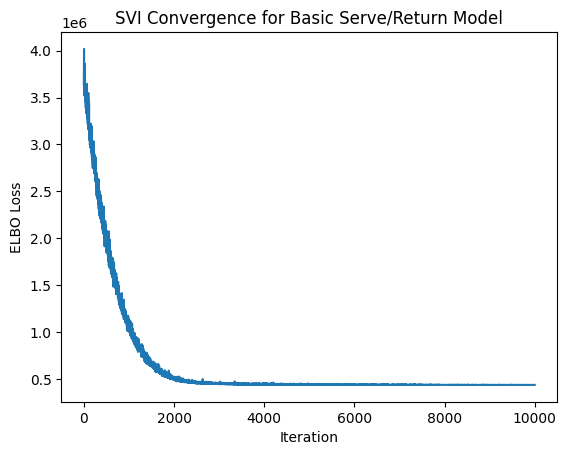

In [22]:
svi_conv_plot(basic_sv_results, 'Basic Serve/Return')

In [27]:
def get_posteriors(guide, params, sample_shape=(5000,), seed=1):
    posteriors = guide.sample_posterior(
        PRNGKey(seed), 
        params, 
        sample_shape=sample_shape
    )
    return posteriors


def posteriors_to_dataframe(posteriors, credible_interval=0.95):
    # Calculate alpha for credible intervals
    alpha = (1 - credible_interval) / 2
    lower_percentile = alpha * 100
    upper_percentile = (1 - alpha) * 100
    
    results = []
    
    for param_name, samples in posteriors.items():
        # Skip internal parameters
        if param_name.startswith("_"):
            continue
        
        # Convert to numpy array
        samples_array = np.array(samples)
        
        # Handle different shapes
        if samples_array.ndim == 1:
            # Single parameter
            results.append({
                'parameter': param_name,
                'mean': float(np.mean(samples_array)),
                'lower_ci': float(np.percentile(samples_array, lower_percentile)),
                'upper_ci': float(np.percentile(samples_array, upper_percentile))
            })
        else:
            # Multiple parameters (e.g., coefficient vector)
            # Flatten all but the first dimension (sample dimension)
            original_shape = samples_array.shape[1:]
            samples_flat = samples_array.reshape(samples_array.shape[0], -1)
            
            for idx in range(samples_flat.shape[1]):
                param_samples = samples_flat[:, idx]
                
                # Create parameter label
                if len(original_shape) == 1:
                    param_label = f"{param_name}[{idx}]"
                else:
                    # Multi-dimensional index
                    multi_idx = np.unravel_index(idx, original_shape)
                    param_label = f"{param_name}{list(multi_idx)}"
                
                results.append({
                    'parameter': param_label,
                    'mean': float(np.mean(param_samples)),
                    'lower_ci': float(np.percentile(param_samples, lower_percentile)),
                    'upper_ci': float(np.percentile(param_samples, upper_percentile))
                })
    
    return pl.DataFrame(results)

In [28]:
posteriors = get_posteriors(guide, basic_sv_results.params, sample_shape=(5000,), seed=1)
#
# Step 2: Create summary dataframe
summary_df = posteriors_to_dataframe(posteriors, credible_interval=0.95)
# print(summary_df)

In [29]:
summary_df.head()

parameter,mean,lower_ci,upper_ci
str,f64,f64,f64
"""intercept""",0.582114,0.564132,0.600308
"""mu_ret""",-0.112391,-0.132338,-0.092143
"""mu_server""",-0.195304,-0.20587,-0.184633
"""player_ret[0]""",-0.119975,-0.392968,0.158386
"""player_ret[1]""",0.107734,0.07089,0.145654


In [30]:
ret_results = summary_df.filter(pl.col("parameter").str.contains("player_ret")).with_columns(
        pl.col("parameter")
        .str.extract(r"\[(\d+)\]", 1)
        .cast(pl.Int64, strict=False)
        .alias("returner_index")
)

player_id_transformed = player_id_encoder.inverse_transform(ret_results['returner_index'])

ret_results = ret_results.with_columns([
    pl.Series(player_id_transformed).alias("player_id")
]).join(link_player_df, on="player_id", how="left")

In [31]:
ret_results.sort('mean', descending=True)

parameter,mean,lower_ci,upper_ci,returner_index,player_id,player_name
str,f64,f64,f64,i64,i64,str
"""player_ret[818]""",0.289632,0.250055,0.329495,818,104753,"""Woong Sun Jun"""
"""player_ret[865]""",0.277548,0.255393,0.299929,865,104926,"""Fabio Fognini"""
"""player_ret[568]""",0.266537,0.235494,0.297588,568,103912,"""Mario Radic"""
"""player_ret[1525]""",0.253299,0.215778,0.290309,1525,208004,"""Harold Mayot"""
"""player_ret[863]""",0.24041,0.20718,0.273759,863,104919,"""Leonardo Mayer"""
…,…,…,…,…,…,…
"""player_ret[642]""",-0.407237,-0.523574,-0.286795,642,104173,"""Sam Warburg"""
"""player_ret[1339]""",-0.42552,-0.583598,-0.267054,1339,126409,"""Hugo Grenier"""
"""player_ret[1089]""",-0.427037,-0.540054,-0.314855,1089,105877,"""Emilio Gomez"""


In [32]:
server_results = summary_df.filter(pl.col("parameter").str.contains("player_server")).with_columns(
        pl.col("parameter")
        .str.extract(r"\[(\d+)\]", 1)
        .cast(pl.Int64, strict=False)
        .alias("server_index")
)

server_id_transformed = player_id_encoder.inverse_transform(server_results['server_index'])

server_results = server_results.with_columns([
    pl.Series(server_id_transformed).alias("player_id")
]).join(link_player_df, on="player_id", how="left")

In [33]:
server_results.sort('mean', descending=True)

parameter,mean,lower_ci,upper_ci,server_index,player_id,player_name
str,f64,f64,f64,i64,i64,str
"""player_server[396]""",0.382062,0.33761,0.428367,396,103337,"""Ben Qiang Zhu"""
"""player_server[1056]""",0.355258,0.317565,0.391695,1056,105688,"""Manuel Sanchez"""
"""player_server[759]""",0.339852,0.303364,0.376087,759,104547,"""Horacio Zeballos"""
"""player_server[611]""",0.331148,0.298859,0.363536,611,104056,"""Roko Karanusic"""
"""player_server[541]""",0.294256,0.250125,0.338019,541,103820,"""Alan Mackin"""
…,…,…,…,…,…,…
"""player_server[1214]""",-0.583894,-0.771411,-0.386732,1214,106415,"""Yoshihito Nishioka"""
"""player_server[278]""",-0.587839,-0.765852,-0.408091,278,102957,"""Vadim Kutsenko"""
"""player_server[1225]""",-0.630562,-0.86459,-0.39722,1225,108996,"""Mahmoud Nader Al Baloushi"""


## Serve + Return + Surface Effect

In [ ]:
from src.models import serve_return_surface_model

new_model_dct = model_dct.copy()
new_model_dct.update(
    surface_idx = np.concatenate([surface_ids, surface_ids]),
    surface_n = len(surface_encoder.classes_)
)

In [36]:
svi_iters = 10000
adam_lr = 0.001
# note - use low rank, its faster when we have a lot of records
surface_guide, surface_sv = model_prep_svi(serve_return_surface_model, 
                                           iterations = svi_iters, 
                                           lr = adam_lr, 
                                           guide_fn = autoguide.AutoLowRankMultivariateNormal)

In [37]:
new_model_dct

{'X_intercept': 1,
 'n_players': 1641,
 'server_idx': array([ 344,  194,  375, ..., 1399, 1260, 1424], shape=(137332,)),
 'returner_idx': array([  16,  201,  115, ..., 1358, 1348, 1616], shape=(137332,)),
 'serve_attempts': array([ 96,  76,  55, ..., 114,  46,  67], shape=(137332,), dtype=int32),
 'serve_pts_won': array([67, 52, 37, ..., 82, 29, 36], shape=(137332,), dtype=int32),
 'surface_idx': array([3, 3, 3, ..., 3, 3, 3], shape=(137332,)),
 'surface_n': 3}

In [38]:
surface_sv_results = surface_sv.run(random.PRNGKey(1), svi_iters, **new_model_dct)

100%|██████████| 10000/10000 [00:29<00:00, 343.12it/s, init loss: 5897044.0000, avg. loss [9501-10000]: 438558.2812]


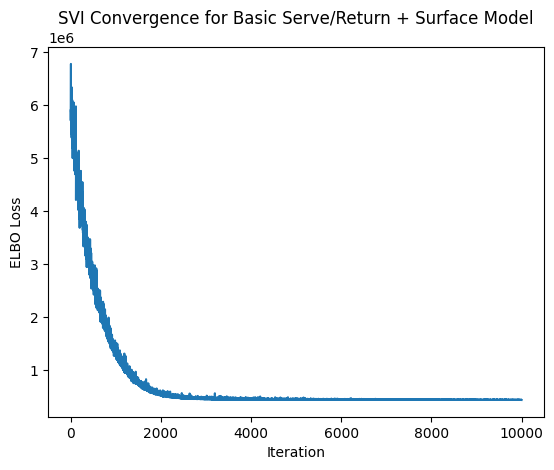

In [39]:
svi_conv_plot(surface_sv_results, 'Basic Serve/Return + Surface')

In [ ]:
surface_posteriors = get_posteriors(surface_guide, surface_sv_results.params, sample_shape=(5000,), seed=1)
surface_summary_df = posteriors_to_dataframe(surface_posteriors, credible_interval=0.95)

surface_results = surface_summary_df.filter(pl.col("parameter").str.contains("surface_effect")).with_columns(
    pl.col("parameter")
    .str.extract(r"\[(\d+)\]", 1)
    .cast(pl.Int64, strict=False)
    .alias("surface_index")
)

surface_names = surface_encoder.inverse_transform(surface_results["surface_index"].to_numpy())

surface_results = surface_results.with_columns(
    pl.Series(surface_names).alias("surface")
).select(["surface", "mean", "lower_ci", "upper_ci"]).sort("mean", descending=True)

surface_results

In [ ]:
surfa

In [ ]:
posteriors = get_posteriors(surface_guide, surface_sv_results.params, sample_shape=(5000,), seed=1)
#
surface_summary_df = posteriors_to_dataframe(posteriors, credible_interval=0.95)
surface_summary_df.head()

parameter,mean,lower_ci,upper_ci
str,f64,f64,f64
"""intercept""",-0.930385,-0.957532,-0.903245
"""mu_ret""",0.94508,0.925056,0.965576
"""mu_server""",-1.227483,-1.238075,-1.216954
"""mu_surface""",1.641808,0.18896,3.021937
"""player_ret[0]""",0.909184,0.612238,1.200203


# Hierarchial Regression w/Time Component 

Goal: To get player effects varying over time. 

(1) AR(1) Covariance in MultiVariate Normal    
(2) State Space Model   